# 9 &middot; Contact: Dropping an Elastic Block on the Floor

Inertia, gravity and contact together: an elastic block is **dropped** onto a flat floor
and bounces. Each Backward-Euler step is one Newton minimization, and we watch the energies
trade off: gravity builds **kinetic** energy on the way down, impact turns it into **contact**
and **elastic** energy, and the rebound hands it back.

$$
x_{n+1} = \arg\min_x\; \tfrac{1}{2h^2}\lVert x - \tilde{x}\rVert_M^2
        + E_{\text{elastic}}(x) + E_{\text{gravity}}(x) + E_{\text{floor}}(x)
$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import igl
import simkit
import utils

NOTEBOOK = "009_contact_plane"                                   # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)  # results/009_contact_plane/
MEDIA_DIR = "media"                                              # tracked copies for the website
# block mesh
NX, NY = 10, 8                         # grid vertices along x and y
WIDTH, HEIGHT = 0.5, 0.5               # block size (m)
DROP_HEIGHT = 1.0                      # initial height of the block's center (m)
# material
MATERIAL = "macklin-mueller-neo-hookean"
YM, PR = 1e5, 0.4                      # Young's modulus (Pa), Poisson ratio
RHO = 1e3                              # density (kg / m^2)
GRAVITY = -9.8                         # vertical acceleration (m / s^2)
# floor
FLOOR_POINT = np.array([0.0, -0.6])    # a point on the floor plane
FLOOR_NORMAL = np.array([0.0, 1.0])    # upward floor normal (keep (0, 1): gravity is along -y, plots draw a flat floor)
K_CONTACT = 1e5                        # contact penalty stiffness
# time stepping
DT = 0.01                              # Backward-Euler timestep (s)
N_STEPS = 130                          # number of timesteps
NEWTON_ITERS = 8                       # max Newton iterations per step
# validation
FD_STEP = 1e-6                         # central-difference step for the gradient check
FD_DEPTH = 0.02                        # how far the gradient-check state sinks into the floor (m)
FD_NOISE = 0.01                        # random vertex jitter of the gradient-check state (m)
SEED = 0                               # RNG seed for that jitter
# plots
FPS = 25                               # animation frame rate
VIEW_LIMS = ((-2 * WIDTH, 2 * WIDTH), (FLOOR_POINT[1] - 0.2, DROP_HEIGHT + HEIGHT / 2 + 0.15))  # scene window (m)

## The block and the floor

A libigl grid, centered, scaled to `WIDTH` x `HEIGHT` and lifted to `DROP_HEIGHT`. The figure
shows it at rest above the floor (gray). Nothing is pinned: gravity alone drives the motion.

80 vertices, 126 triangles, bottom of the block 1.35 m above the floor


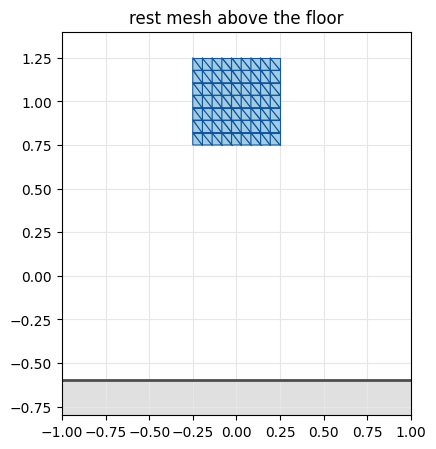

In [2]:
V, T = igl.triangulated_grid(NX, NY)                   # unit square, NX x NY vertices
X = (V - 0.5) * np.array([WIDTH, HEIGHT])              # centered WIDTH x HEIGHT block
X[:, 1] += DROP_HEIGHT                                 # start up high
n, dim = X.shape
print(f"{n} vertices, {len(T)} triangles, bottom of the block {((X - FLOOR_POINT) @ FLOOR_NORMAL).min():.2f} m above the floor")

fig, ax = plt.subplots(figsize=(4.5, 5))
utils.plot_mesh(ax, X, T, title="rest mesh above the floor", lims=VIEW_LIMS)
ax.axhline(FLOOR_POINT[1], color="0.3", lw=2)
ax.fill_between(VIEW_LIMS[0], VIEW_LIMS[1][0], FLOOR_POINT[1], color="0.88", zorder=1)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh.png"),
                              copy_to=os.path.join(MEDIA_DIR, "009_mesh.png"))
plt.show()

## Constant operators

Built once from the rest shape: the deformation Jacobian `J`, triangle areas `vol`, Lamé
parameters, the lumped vertex mass `M_n` (and its per-coordinate `M`), and the gravity force
`f_g`. Every triangle has the same area (left), so $m_i$, a third of the mass of the triangles
meeting at vertex $i$, depends only on how many meet there (right). The mass also weights the
floor, $E_{\text{floor}} = \tfrac{k}{2}\sum_i m_i \min\!\big(0,\, n^\top(x_i - p)\big)^2$,
so vertex $i$'s floor spring has stiffness $k\,m_i$. Interior vertices carry the most mass
(3.97 kg), but only the bottom row ever touches the floor: its edge vertices carry half that
(1.98 kg), and its two corners differ, 0.66 kg on the left (one triangle) vs 1.32 kg on the
right (two).

triangle area from 1.984e-03 to 1.984e-03 m^2, total mass 250.0 kg, vertex mass from 0.66 to 3.97 kg


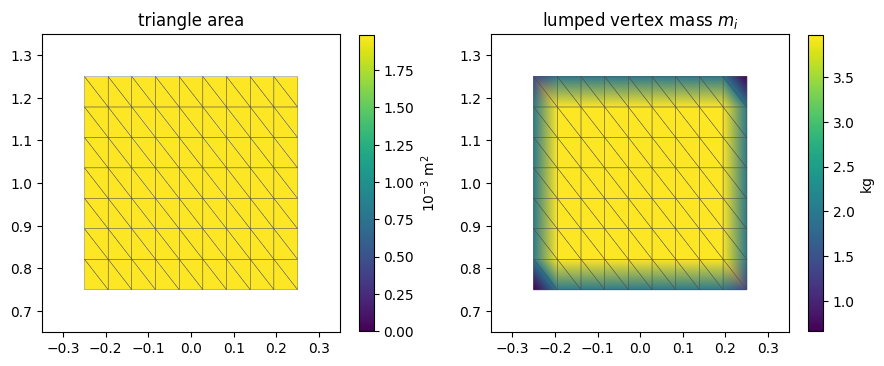

In [3]:
J = simkit.deformation_jacobian(X, T)
vol = simkit.volume(X, T)
mu_s, lam_s = simkit.ympr_to_lame(YM, PR)
mu = np.full((len(T), 1), mu_s)
lam = np.full((len(T), 1), lam_s)
M_n = simkit.massmatrix(X, T, rho=RHO)                           # (n x n) lumped vertex mass
M = sp.sparse.kron(M_n, sp.sparse.eye(dim)).tocsc()               # (n*dim x n*dim)
f_g = simkit.gravity_force(X, T, a=GRAVITY, rho=RHO).reshape(-1, 1)
print(f"triangle area from {vol.min():.3e} to {vol.max():.3e} m^2, total mass {M_n.diagonal().sum():.1f} kg, "
      f"vertex mass from {M_n.diagonal().min():.2f} to {M_n.diagonal().max():.2f} kg")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9, 4))
utils.plot_scalar_field(axL, X, T, 1e3 * vol, title="triangle area", vmin=0.0,
                        cmap="viridis", label=r"$10^{-3}$ m$^2$")
utils.plot_scalar_field(axR, X, T, M_n.diagonal(), title="lumped vertex mass $m_i$",
                        cmap="viridis", label="kg")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "vertex_mass.png"),
                              copy_to=os.path.join(MEDIA_DIR, "009_vertex_mass.png"))
plt.show()

## The drop system

`drop_system(x_curr, x_prev)` is the objective of one Backward-Euler step, one simkit term per
line: elastic, gravity ($-f_g^\top x$, linear, so no Hessian term), the floor penalty, and
inertia. `kinetic_energy_be` rebuilds the momentum prediction $\tilde{x} = x_n + h\,v_n$ with
$v_n = (x_n - x_{n-1})/h$ from the two latest states.

In [4]:
def drop_system(x_curr, x_prev):
    """Elastic + gravity + floor contact + Backward-Euler inertia, in stacked positions x."""

    def energy_func(x):
        E_elastic = simkit.energies.elastic_energy_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        E_gravity = -(f_g.T @ x).item()
        E_floor = simkit.energies.contact_springs_plane_energy(x.reshape(n, dim), K_CONTACT, FLOOR_POINT, FLOOR_NORMAL, M=M_n)
        E_inertia = simkit.energies.kinetic_energy_be(x, x_curr, x_prev, M, DT)
        E_total = E_elastic + E_gravity + E_floor + E_inertia
        return E_total

    def gradient_func(x):
        g_elastic = simkit.energies.elastic_gradient_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL)
        g_gravity = -f_g
        g_floor = simkit.energies.contact_springs_plane_gradient(x.reshape(n, dim), K_CONTACT, FLOOR_POINT, FLOOR_NORMAL, M=M_n)
        g_inertia = simkit.energies.kinetic_gradient_be(x, x_curr, x_prev, M, DT)
        g_total = g_elastic + g_gravity + g_floor + g_inertia
        return g_total

    def hessian_func(x):
        H_elastic = simkit.energies.elastic_hessian_x(x.reshape(n, dim), J, mu, lam, vol, MATERIAL, psd=True)
        H_floor = simkit.energies.contact_springs_plane_hessian(x.reshape(n, dim), K_CONTACT, FLOOR_POINT, FLOOR_NORMAL, M=M_n)
        H_inertia = simkit.energies.kinetic_hessian_be(M, DT)
        H_total = H_elastic + H_floor + H_inertia
        return H_total

    return energy_func, gradient_func, hessian_func

A central-difference check of `gradient_func` before simulating: we lower the block until its
bottom row is `FD_DEPTH` inside the floor and jitter every vertex, so all four terms, contact
included, are active. The relative error is at round-off level, so the gradient is right.

In [5]:
rng = np.random.default_rng(SEED)
U_test = X + np.array([0.0, FLOOR_POINT[1] - FD_DEPTH - X[:, 1].min()])     # bottom row below the floor
x_test = (U_test + FD_NOISE * rng.standard_normal(X.shape)).reshape(-1, 1)
energy_func, gradient_func, hessian_func = drop_system(U_test.reshape(-1, 1), U_test.reshape(-1, 1))
g_analytic = gradient_func(x_test).ravel()
g_fd = simkit.gradient_cfd(lambda y: np.array(energy_func(y.reshape(-1, 1))), x_test.ravel(), FD_STEP)
print(f"relative gradient error |g_fd - g| / |g| = {np.linalg.norm(g_fd - g_analytic) / np.linalg.norm(g_analytic):.2e}")

relative gradient error |g_fd - g| / |g| = 4.41e-11


## Run the drop

The block starts at rest (`x_prev = x_curr`). Every step rebuilds the system around the two
latest states and Newton-solves it. We record the elastic, kinetic $\tfrac12 v^\top M v$,
contact and gravitational energies, plus two residuals: the deepest floor penetration and the
gradient norm Newton leaves behind (and how many iterations it took).

In [6]:
x0 = X.reshape(-1, 1)
x_curr = x0.copy()
x_prev = x0.copy()
states, t_axis = [X.copy()], [0.0]
E_el, E_kin, E_con, E_grav = [0.0], [0.0], [0.0], [0.0]
penetration, grad_norm, newton_iters = [0.0], [], []
for step in range(N_STEPS):
    energy_func, gradient_func, hessian_func = drop_system(x_curr, x_prev)
    x_next, info = simkit.solvers.newton_solver(x_curr, energy_func, gradient_func, hessian_func,
                                                max_iter=NEWTON_ITERS, do_line_search=True, return_info=True)
    U_next = x_next.reshape(n, dim)
    v = simkit.energies.velocity_be(x_next, x_curr, DT)
    E_el.append(simkit.energies.elastic_energy_x(U_next, J, mu, lam, vol, MATERIAL))
    E_kin.append(0.5 * (v.T @ M @ v).item())
    E_con.append(simkit.energies.contact_springs_plane_energy(U_next, K_CONTACT, FLOOR_POINT, FLOOR_NORMAL, M=M_n))
    E_grav.append(-(f_g.T @ (x_next - x0)).item())                    # relative to the start
    penetration.append(max(0.0, -((U_next - FLOOR_POINT) @ FLOOR_NORMAL).min()))
    grad_norm.append(np.linalg.norm(gradient_func(x_next)))
    newton_iters.append(info["iters"] + 1)
    states.append(U_next.copy())
    t_axis.append((step + 1) * DT)
    x_prev, x_curr = x_curr, x_next

t_axis = np.array(t_axis)
series = {"elastic": np.array(E_el), "kinetic": np.array(E_kin), "contact": np.array(E_con)}
E_mech = series["elastic"] + series["kinetic"] + series["contact"] + np.array(E_grav)
i_impact = int(np.argmax(E_con))
print(f"impact near t = {t_axis[i_impact]:.2f}s, peak kinetic {series['kinetic'].max():.0f} J, "
      f"peak elastic {series['elastic'].max():.0f} J, peak contact {series['contact'].max():.0f} J")
print(f"mechanical energy dissipated by t = {t_axis[-1]:.2f}s: {-E_mech[-1]:.0f} J "
      f"of the {-E_grav[-1]:.0f} J released by the fall")

impact near t = 0.55s, peak kinetic 3236 J, peak elastic 1391 J, peak contact 300 J
mechanical energy dissipated by t = 1.30s: 3256 J of the 3312 J released by the fall


Left: kinetic energy grows quadratically in free fall, and impact (contact peaks at 0.55 s) turns it into
elastic and contact energy within a few steps before the rebound. Right: the total mechanical
energy (kinetic + elastic + contact + gravitational), which an exact integrator would keep at
zero. It drifts slowly in free fall ($\tfrac12 m h^2 g^2 \approx 1.2$ J per step) and plunges at
each impact, where Backward Euler damps the stiff contact response: the first impact removes
about 2700 of the 3300 J the fall released. By t = 1.3 s, 3256 of the 3312 J released is gone
(printed above), leaving only about 56 J of motion and deformation.

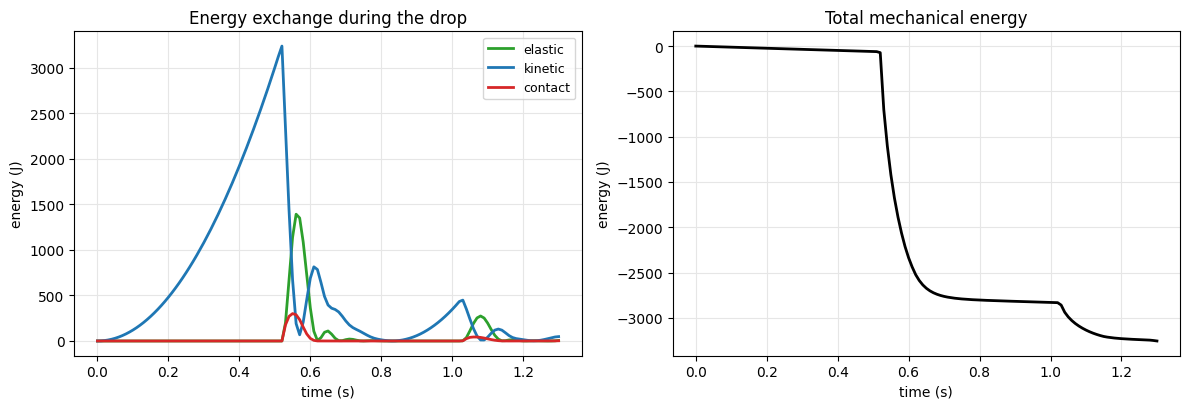

In [7]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2))
utils.line_plot(t_axis, series, xlabel="time (s)", ylabel="energy (J)",
                colors=utils.ENERGY_COLORS, title="Energy exchange during the drop", ax=axL)
utils.line_plot(t_axis, {"total": E_mech}, xlabel="time (s)", ylabel="energy (J)",
                colors=utils.ENERGY_COLORS, title="Total mechanical energy", ax=axR)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "energy.png"),
                              copy_to=os.path.join(MEDIA_DIR, "009_energy.png"))
plt.show()

Two residuals over time. Penalty contact lets vertices sink into the floor while it pushes
back, up to 20 mm at the first impact (left). The gradient Newton leaves behind, relative to
the norm of the nodal gravity forces $\lVert f_g\rVert$, is below $10^{-12}$ in free fall and
jumps to about $3\cdot10^{-4}$ at impact, where Newton uses all `NEWTON_ITERS` iterations
(right, and printed). It stays below $10^{-3}$ throughout, so every step is solved accurately
enough.

steps that used all 8 Newton iterations: t = [0.53 0.54 0.55 0.56] s


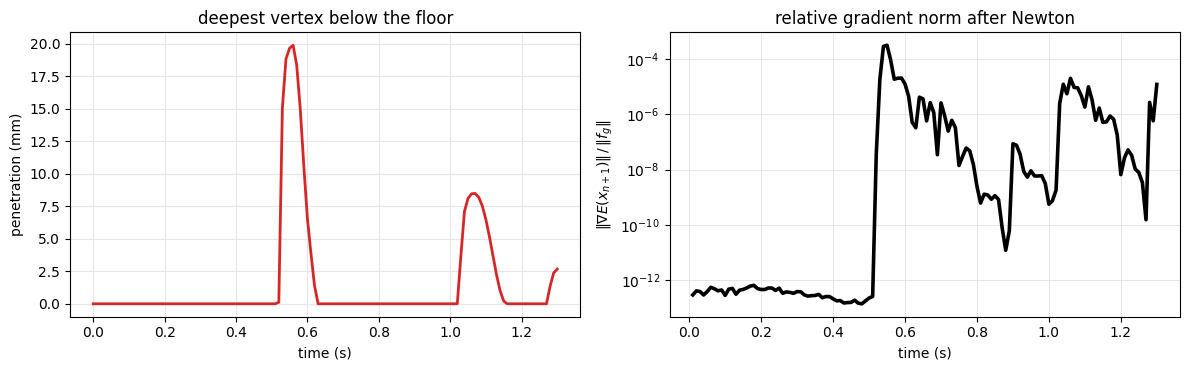

In [8]:
capped = t_axis[1:][np.array(newton_iters) >= NEWTON_ITERS]
print(f"steps that used all {NEWTON_ITERS} Newton iterations: t = {np.round(capped, 2)} s")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 3.8))
utils.line_plot(t_axis, {"contact": 1e3 * np.array(penetration)}, xlabel="time (s)", ylabel="penetration (mm)",
                colors=utils.ENERGY_COLORS, title="deepest vertex below the floor", ax=axL)
utils.residual_plot({"gradient": np.array(grad_norm) / np.linalg.norm(f_g)}, t_axis[1:], ax=axR,
                    colors={"gradient": "k"}, xlabel="time (s)", ylabel=r"$\|\nabla E(x_{n+1})\| \,/\, \|f_g\|$",
                    title="relative gradient norm after Newton")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "residuals.png"),
                              copy_to=os.path.join(MEDIA_DIR, "009_residuals.png"))
plt.show()

## At peak impact

The frame with the largest contact energy, colored by the per-triangle elastic energy density
$\psi(F)$ (left) and each vertex's penetration depth (right). The bottom rows, squeezed between
the falling block and the floor, store most of the elastic energy and bulge sideways, and the
whole bottom row sits inside the floor.

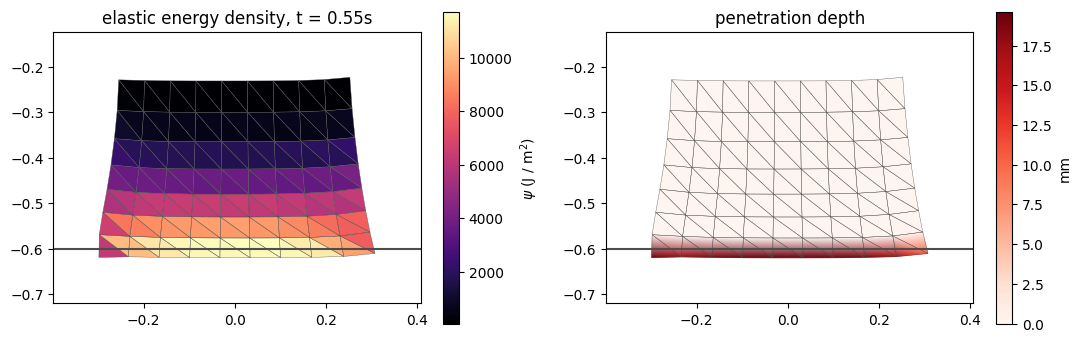

In [9]:
U_impact = states[i_impact]
F_impact = simkit.deformation_gradient(X, T, U_impact)
psi_impact = simkit.energies.elastic_energy_element_F(F_impact, mu, lam, MATERIAL)
depth_impact = np.maximum(0.0, -((U_impact - FLOOR_POINT) @ FLOOR_NORMAL))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
utils.plot_scalar_field(axL, U_impact, T, psi_impact, title=f"elastic energy density, t = {t_axis[i_impact]:.2f}s",
                        cmap="magma", label=r"$\psi$ (J / m$^2$)")
utils.plot_scalar_field(axR, U_impact, T, 1e3 * depth_impact, title="penetration depth",
                        cmap="Reds", label="mm")
for ax in (axL, axR):
    ax.axhline(FLOOR_POINT[1], color="0.3", lw=1.5)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "impact_fields.png"),
                              copy_to=os.path.join(MEDIA_DIR, "009_impact_fields.png"))
plt.show()

The whole drop, with the energy curves traced in lock-step: a hard first bounce, a much
smaller second one, and the block settling slightly tilted.

In [10]:
fig, anim = utils.animate_dynamics(states, T, t_axis, series, lims=VIEW_LIMS,
    xlabel="time (s)", ylabel="energy (J)", colors=utils.ENERGY_COLORS, floor_y=FLOOR_POINT[1],
    scene_title="elastic block dropping on the floor",
    title="elastic / kinetic / contact energy", fps=FPS)
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "contact_plane.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "009_contact_plane.mp4"))
plt.close(fig)
utils.embed_video(video)

### Takeaways
* Gravity &rarr; **kinetic** on the way down; impact &rarr; **elastic** + **contact**; the rebound reverses it.
* The **contact** penalty spikes exactly at impact, and lets vertices sink up to 20 mm into the floor.
* Backward Euler damps the stiff impact, so each bounce loses most of the energy and the block
  never bounces back to full height.